In [1]:
import sys
sys.path.append('..')
from run.run_gspa import calculate_wavelet_dictionary
from run.run_ae_default_config import run_ae
import leidenalg
import scanpy, phate, meld
import numpy as np
import scprep
import matplotlib.pyplot as plt
import pandas as pd
from utils import *
import sklearn
from sklearn.preprocessing import scale
import magic

/home/aarthivenkat/.local/lib/python3.8/site-packages/pandas/core/computation/expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
markers = ["Mki67", 'Birc5', 'Pclaf', 'Top2a', 'Hist1h1b', 'Stmn1',
           "Tcf7", "Lef1", "Ccr7", "Sell",
           "Slamf6", 'Xcl1',
           "Il7r", "Malat1", "Cxcr3", "Ltb", "Gpr183",
           "Irf7", "Stat1", 'Isg20', 'Ifit1', 'Ifit3', 'Isg15',
           "Nkg7", "Ccl5", "Ly6c2", "Lgals1", "Prf1", "Klrg1", "Cx3cr1", "Klre1", "Zeb2", "Gzma",
           "Pdcd1", "Cd101", "Havcr2"]

In [3]:
acute = scanpy.read_h5ad('data/acute_tcells.h5ad')
chronic = scanpy.read_h5ad('data/chronic_tcells.h5ad')

In [4]:
adata = scanpy.concat((acute,chronic))
adata.obs['batch'] = adata.obs['batch'].astype('category')

## Generate GSPA+QR features for acute graph

In [4]:
phate_op = phate.PHATE(random_state=42, n_jobs=-1, knn=30)
acute.obsm['X_phate'] = phate_op.fit_transform(acute.to_df())

Calculating PHATE...
  Running PHATE on 22901 observations and 14583 variables.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 10.65 seconds.
    Calculating KNN search...
    Calculated KNN search in 15.18 seconds.
    Calculating affinities...
    Calculated affinities in 2.14 seconds.
  Calculated graph and diffusion operator in 28.25 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 6.25 seconds.
    Calculating KMeans...
    Calculated KMeans in 3.30 seconds.
  Calculated landmark operator in 11.08 seconds.
  Calculating optimal t...
    Automatically selected t = 25
  Calculated optimal t in 1.77 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.72 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 4.17 seconds.
Calculated PHATE in 46.00 seconds.


In [5]:
G_without_regression = phate_op.graph.to_pygsp()

In [35]:
data, data_hvgs = scprep.select.highly_variable_genes(acute.to_df(), acute.var_names, percentile=90)
data_hvg = data[data_hvgs]
data_hvg = data_hvg / np.linalg.norm(data_hvg, axis=0)

In [7]:
uniform_signal = np.ones((1, G_without_regression.N))
uniform_signal = uniform_signal / np.linalg.norm(uniform_signal, axis=1).reshape(-1,1)

In [8]:
cell_dictionary, wavelet_sizes = calculate_wavelet_dictionary(G_without_regression, use_reduced=True, J=5)

Maximum scale: 5


100%|██████████| 3/3 [57:40<00:00, 1153.35s/it]


In [9]:
results = {}

signals_projected = project(data_hvg.T, cell_dictionary)
signals_reduced = svd(signals_projected)
results['signal_embedding'] = run_ae(signals_reduced)
np.savez('results/GSPA_QR_acute_without_regression.npz', signal_embedding=results['signal_embedding'])

Epoch 1/100
44/44 [==============================] - 1s 8ms/step - loss: 0.0039 - val_loss: 0.0040
Epoch 2/100
44/44 [==============================] - 0s 6ms/step - loss: 0.0027 - val_loss: 0.0025
Epoch 3/100
44/44 [==============================] - 0s 6ms/step - loss: 0.0018 - val_loss: 0.0020
Epoch 4/100
44/44 [==============================] - 0s 6ms/step - loss: 0.0015 - val_loss: 0.0017
Epoch 5/100
44/44 [==============================] - 0s 5ms/step - loss: 0.0013 - val_loss: 0.0016
Epoch 6/100
44/44 [==============================] - 0s 5ms/step - loss: 0.0012 - val_loss: 0.0015
Epoch 7/100
44/44 [==============================] - 0s 5ms/step - loss: 0.0011 - val_loss: 0.0015
Epoch 8/100
44/44 [==============================] - 0s 5ms/step - loss: 0.0011 - val_loss: 0.0014
Epoch 9/100
44/44 [==============================] - 0s 5ms/step - loss: 0.0010 - val_loss: 0.0014
Epoch 10/100
44/44 [==============================] - 0s 5ms/step - loss: 9.9356e-04 - val_loss: 0.0014
Epoch

In [11]:
uniform_projected = project(uniform_signal, cell_dictionary)
results['localization_score'] = calculate_distance_to_signal(uniform_projected, signals_projected)
np.savez('./results/GSPA_QR_acute_without_regression.npz', signal_embedding=results['signal_embedding'],
         localization_score=results['localization_score'], genes=data_hvgs.values)

## Generate GSPA+QR features for chronic graph

In [12]:
phate_op = phate.PHATE(random_state=42, n_jobs=-1, knn=30)
chronic.obsm['X_phate'] = phate_op.fit_transform(chronic.to_df())

Calculating PHATE...
  Running PHATE on 21289 observations and 14769 variables.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 9.20 seconds.
    Calculating KNN search...
    Calculated KNN search in 14.08 seconds.
    Calculating affinities...
    Calculated affinities in 1.16 seconds.
  Calculated graph and diffusion operator in 24.70 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 7.07 seconds.
    Calculating KMeans...
    Calculated KMeans in 3.31 seconds.
  Calculated landmark operator in 11.91 seconds.
  Calculating optimal t...
    Automatically selected t = 25
  Calculated optimal t in 1.81 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.41 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 5.70 seconds.
Calculated PHATE in 44.53 seconds.


In [13]:
G_without_regression = phate_op.graph.to_pygsp()

In [14]:
data, data_hvgs = scprep.select.highly_variable_genes(chronic.to_df(), chronic.var_names, percentile=90)
data_hvg = data[data_hvgs]
data_hvg = data_hvg / np.linalg.norm(data_hvg, axis=0)

In [15]:
uniform_signal = np.ones((1, G_without_regression.N))
uniform_signal = uniform_signal / np.linalg.norm(uniform_signal, axis=1).reshape(-1,1)

In [16]:
cell_dictionary, wavelet_sizes = calculate_wavelet_dictionary(G_without_regression, use_reduced=True, J=5)

Maximum scale: 5


100%|██████████| 3/3 [51:43<00:00, 1034.57s/it]


In [17]:
results = {}

signals_projected = project(data_hvg.T, cell_dictionary)
signals_reduced = svd(signals_projected)
results['signal_embedding'] = run_ae(signals_reduced)
np.savez('results/GSPA_QR_chronic_without_regression.npz', signal_embedding=results['signal_embedding'])

Epoch 1/100
44/44 [==============================] - 1s 8ms/step - loss: 0.0055 - val_loss: 0.0048
Epoch 2/100
44/44 [==============================] - 0s 6ms/step - loss: 0.0039 - val_loss: 0.0031
Epoch 3/100
44/44 [==============================] - 0s 6ms/step - loss: 0.0025 - val_loss: 0.0025
Epoch 4/100
44/44 [==============================] - 0s 6ms/step - loss: 0.0021 - val_loss: 0.0022
Epoch 5/100
44/44 [==============================] - 0s 6ms/step - loss: 0.0018 - val_loss: 0.0020
Epoch 6/100
44/44 [==============================] - 0s 6ms/step - loss: 0.0016 - val_loss: 0.0019
Epoch 7/100
44/44 [==============================] - 0s 6ms/step - loss: 0.0015 - val_loss: 0.0018
Epoch 8/100
44/44 [==============================] - 0s 5ms/step - loss: 0.0015 - val_loss: 0.0017
Epoch 9/100
44/44 [==============================] - 0s 6ms/step - loss: 0.0014 - val_loss: 0.0017
Epoch 10/100
44/44 [==============================] - 0s 6ms/step - loss: 0.0014 - val_loss: 0.0017
Epoch 11/

In [18]:
uniform_projected = project(uniform_signal, cell_dictionary)
results['localization_score'] = calculate_distance_to_signal(uniform_projected, signals_projected)
np.savez('./results/GSPA_QR_chronic_without_regression.npz', signal_embedding=results['signal_embedding'],
         localization_score=results['localization_score'], genes=data_hvgs.values)

## Mask

In [7]:
APC_markers = ['Cd79a', 'Ebf1', 'Cd79b', 'Ly6d', 'Iglc3', 'Iglc2', 'H2-Ab1', 'H2-Aa', 'H2-Eb1', 'Cd74', 'Ms4a1']

In [55]:
acute_mask = (np.sum(acute.to_df()[APC_markers] > 0, axis=1) > 1)

In [56]:
chronic_mask = (np.sum(chronic.to_df()[APC_markers] > 0, axis=1) > 1)

In [57]:
acute=acute[~acute_mask]

In [58]:
chronic=chronic[~chronic_mask]

In [59]:
adata = scanpy.concat((acute,chronic))
adata.obs['batch'] = adata.obs['batch'].astype('category')

In [6]:
phate_op = phate.PHATE(random_state=42, n_jobs=-1, knn=30)
adata.obsm['X_phate'] = phate_op.fit_transform(adata.to_df())

Calculating PHATE...
  Running PHATE on 20000 observations and 14152 variables.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 9.56 seconds.
    Calculating KNN search...
    Calculated KNN search in 12.19 seconds.
    Calculating affinities...
    Calculated affinities in 1.42 seconds.
  Calculated graph and diffusion operator in 23.45 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 7.93 seconds.
    Calculating KMeans...
    Calculated KMeans in 9.85 seconds.
  Calculated landmark operator in 19.18 seconds.
  Calculating optimal t...
    Automatically selected t = 16
  Calculated optimal t in 1.62 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.33 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 4.40 seconds.
Calculated PHATE in 48.98 seconds.


In [61]:
from sklearn import cluster

In [62]:
clusters = cluster.KMeans(n_clusters=10).fit_predict(phate_op.graph.data_nu)

In [71]:
adata = adata[clusters != 7]

In [78]:
acute = adata[adata.obs['batch'].str.startswith('Acute')]

In [79]:
chronic = adata[adata.obs['batch'].str.startswith('Chronic')]

In [81]:
acute.write('data/acute_tcells.h5ad')

In [82]:
chronic.write('data/chronic_tcells.h5ad')

## Generate GSPA+QR features

In [5]:
scanpy.pp.subsample(adata, n_obs=20000, random_state=0)

In [6]:
phate_op = phate.PHATE(random_state=42, n_jobs=-1, knn=30)
adata.obsm['X_phate'] = phate_op.fit_transform(adata.to_df())

Calculating PHATE...
  Running PHATE on 20000 observations and 14152 variables.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 9.56 seconds.
    Calculating KNN search...
    Calculated KNN search in 12.19 seconds.
    Calculating affinities...
    Calculated affinities in 1.42 seconds.
  Calculated graph and diffusion operator in 23.45 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 7.93 seconds.
    Calculating KMeans...
    Calculated KMeans in 9.85 seconds.
  Calculated landmark operator in 19.18 seconds.
  Calculating optimal t...
    Automatically selected t = 16
  Calculated optimal t in 1.62 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.33 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 4.40 seconds.
Calculated PHATE in 48.98 seconds.


In [12]:
cmap = dict([(sample,plt.cm.Paired.colors[:6][i]) for i,sample in enumerate(['AcuteD4', 'ChronicD4', 'AcuteD8', 'ChronicD8', 'Acute40', 'Chronic40'])])

<AxesSubplot:>

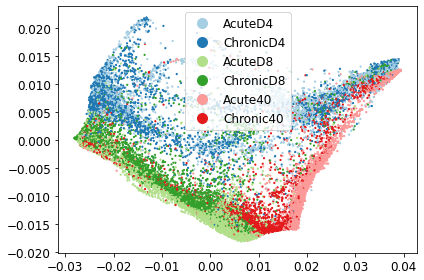

In [13]:
scprep.plot.scatter2d(adata.obsm['X_phate'], c=adata.obs['batch'], cmap=cmap)

In [14]:
G_without_regression = phate_op.graph.to_pygsp()

In [16]:
data, data_hvgs = scprep.select.highly_variable_genes(adata.to_df(), adata.var_names, percentile=90)
data_hvg = data[data_hvgs]
data_hvg = data_hvg / np.linalg.norm(data_hvg, axis=0)

In [19]:
uniform_signal = np.ones((1, G_without_regression.N))
uniform_signal = uniform_signal / np.linalg.norm(uniform_signal, axis=1).reshape(-1,1)

In [20]:
cell_dictionary, wavelet_sizes = calculate_wavelet_dictionary(G_without_regression, use_reduced=True, J=5)

Maximum scale: 5


100%|██████████| 3/3 [44:05<00:00, 881.91s/it]


In [21]:
results = {}

signals_projected = project(data_hvg.T, cell_dictionary)
signals_reduced = svd(signals_projected)
results['signal_embedding'] = run_ae(signals_reduced)
np.savez('results/GSPA_QR_without_regression.npz', signal_embedding=results['signal_embedding'])

Epoch 1/100
43/43 [==============================] - 1s 8ms/step - loss: 0.0044 - val_loss: 0.0038
Epoch 2/100
43/43 [==============================] - 0s 5ms/step - loss: 0.0029 - val_loss: 0.0025
Epoch 3/100
43/43 [==============================] - 0s 5ms/step - loss: 0.0019 - val_loss: 0.0020
Epoch 4/100
43/43 [==============================] - 0s 5ms/step - loss: 0.0016 - val_loss: 0.0018
Epoch 5/100
43/43 [==============================] - 0s 5ms/step - loss: 0.0014 - val_loss: 0.0017
Epoch 6/100
43/43 [==============================] - 0s 5ms/step - loss: 0.0013 - val_loss: 0.0016
Epoch 7/100
43/43 [==============================] - 0s 5ms/step - loss: 0.0012 - val_loss: 0.0015
Epoch 8/100
43/43 [==============================] - 0s 6ms/step - loss: 0.0012 - val_loss: 0.0015
Epoch 9/100
43/43 [==============================] - 0s 6ms/step - loss: 0.0011 - val_loss: 0.0014
Epoch 10/100
43/43 [==============================] - 0s 6ms/step - loss: 0.0011 - val_loss: 0.0014
Epoch 11/

In [22]:
uniform_projected = project(uniform_signal, cell_dictionary)
results['localization_score'] = calculate_localization(uniform_projected, signals_projected)
np.savez('./results/GSPA_QR_without_regression.npz', signal_embedding=results['signal_embedding'],
         localization_score=results['localization_score'], genes=data_hvgs.values)

## Regress out proliferation
https://nbviewer.org/github/scverse/scanpy_usage/blob/master/180209_cell_cycle/cell_cycle.ipynb

In [28]:
!if [ ! -f data/regev_lab_cell_cycle_genes.txt ]; then curl -o data/regev_lab_cell_cycle_genes.txt https://raw.githubusercontent.com/theislab/scanpy_usage/master/180209_cell_cycle/data/regev_lab_cell_cycle_genes.txt; fi

In [39]:
cell_cycle_genes = [x.strip() for x in open('./data/regev_lab_cell_cycle_genes.txt')]
cell_cycle_genes = [x.capitalize() for x in cell_cycle_genes]

print(len(cell_cycle_genes))

# Split into 2 lists
s_genes = cell_cycle_genes[:43]
g2m_genes = cell_cycle_genes[43:]

cell_cycle_genes = [x for x in cell_cycle_genes if x in adata.var_names]
print(len(cell_cycle_genes))

In [31]:
scanpy.tl.score_genes_cell_cycle(adata, s_genes=s_genes, g2m_genes=g2m_genes)

In [32]:
adata_regressed = scanpy.pp.regress_out(adata, ['S_score', 'G2M_score'], copy=True)
scanpy.pp.scale(adata_regressed)

In [33]:
phate_op = phate.PHATE(random_state=42, n_jobs=-1, knn=30)
adata_regressed.obsm['X_phate'] = phate_op.fit_transform(adata_regressed.to_df())

Calculating PHATE...
  Running PHATE on 44190 observations and 14152 variables.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 21.14 seconds.
    Calculating KNN search...
    Calculated KNN search in 61.14 seconds.
    Calculating affinities...
    Calculated affinities in 7.63 seconds.
  Calculated graph and diffusion operator in 90.52 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 23.65 seconds.
    Calculating KMeans...
    Calculated KMeans in 5.00 seconds.
  Calculated landmark operator in 31.14 seconds.
  Calculating optimal t...
    Automatically selected t = 33
  Calculated optimal t in 1.70 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.46 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 5.67 seconds.
Calculated PHATE in 129.52 seconds.


In [34]:
G_with_regression = phate_op.graph

In [ ]:
scprep.plot.scatter2d(adata_regressed.obsm['X_phate'], c=adata_regressed.obs['batch'], ticks=None, legend_loc=(1.05,0), 
                      filename='./figures/samples_tcells_regressed.png', dpi=200, title='Cd3e+ cells')

In [ ]:
meld_op = meld.MELD()
meld_op.graph = G_with_regression
all_sample_densities = meld_op.transform(adata_regressed.obs['batch'])
all_sample_likelihoods = meld.normalize_densities(all_sample_densities)
adata_regressed.obs[[f'{x}_likelihood' for x in all_sample_likelihoods.columns]] = all_sample_likelihoods.values

In [ ]:
fig, ax = plt.subplots(2,3, figsize=(13,8), dpi=200); ax=ax.flatten()

for i,condition in enumerate(adata_regressed.obs['batch'].cat.categories):
    scprep.plot.scatter2d(adata_regressed.obsm['X_phate'], c=adata_regressed.obs[f'{condition}_likelihood'],
                     title=condition, label_prefix='Cell PHATE', ticks=None, ax=ax[i],
                      cmap=meld.get_meld_cmap())
    
plt.tight_layout()
fig.savefig('./figures/conditions_regressed.png', dpi=200)

In [ ]:
fig, ax = plt.subplots(6,6, figsize=(24,24), dpi=200); ax=ax.flatten()

for i,marker in enumerate(markers):
    scprep.plot.scatter2d(adata_regressed.obsm['X_phate'], c=adata_regressed.to_df()[marker],
                     title=marker, label_prefix='Cell PHATE', ticks=None, ax=ax[i])
    
plt.tight_layout()
fig.savefig('./figures/markers_regressed.png', dpi=200)

## Generate GSPA+QR features

In [ ]:
G_with_regression = G_with_regression.to_pygsp()

In [ ]:
uniform_signal = np.ones((1, G_with_regression.N))
uniform_signal = uniform_signal / np.linalg.norm(uniform_signal, axis=1).reshape(-1,1)

In [ ]:
cell_dictionary, wavelet_sizes = calculate_wavelet_dictionary(G_with_regression, use_reduced=True)

In [ ]:
data_hvg, data_hvgs = scprep.select.highly_variable_genes(adata_regressed.to_df(), adata_regressed.var_names, percentile=90)
data_hvg = data[:, data_hvgs]
data_hvg = data_hvg / np.linalg.norm(data_hvg, axis=0)

In [ ]:
results = {}

signals_projected = project(data_hvg.T, cell_dictionary)
signals_reduced = svd(signals_projected)
results['signal_embedding'] = run_ae(signals_reduced)
np.savez('./results/GSPA_QR_with_regression.npz', signal_embedding=results['signal_embedding'])

In [ ]:
uniform_projected = project(uniform_signal, cell_dictionary)
results['localization_score'] = calculate_localization(uniform_projected, signals_projected)
np.savez('./results/GSPA_QR_with_regression.npz', signal_embedding=results['signal_embedding'],
         localization_score=results['localization_score'])